## Libraries

In [ ]:
# Prevent OpenMP runtime conflict between libraries like PyTorch, TensorFlow, and NumPy on Windows
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import danflow.data as data
import danflow.training as training
import danflow.visualization as visualization

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, PowerTransformer

## Load dataset

In [ ]:
data.extract_zip(
    zip_path="../data/shuttle.zip",
    output_path="../data"
)

In [ ]:
data.delimited_to_csv(
    input_path="../data/shuttle.trn",
    output_path="../data/train.csv"
)

In [ ]:
df = pd.read_csv("../data/train.csv", header=None)
df.columns = [
    "feature_1",
    "feature_2",
    "feature_3",
    "feature_4",
    "feature_5",
    "feature_6",
    "feature_7",
    "feature_8",
    "feature_9",
    "target",
]
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,50,21,77,0,28,0,27,48,22,2
1,55,0,92,0,0,26,36,92,56,4
2,53,0,82,0,52,-5,29,30,2,1
3,37,0,76,0,28,18,40,48,8,1
4,37,0,79,0,34,-26,43,46,2,1


<h2 align="center">1. Data Understanding</h2>

Initial exploration of the dataset structure, features, and basic statistics.

### 1.1. Dataset Structure

Display summary information about the dataset including column names, data types, and non-null counts.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43500 entries, 0 to 43499
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   feature_1  43500 non-null  int64
 1   feature_2  43500 non-null  int64
 2   feature_3  43500 non-null  int64
 3   feature_4  43500 non-null  int64
 4   feature_5  43500 non-null  int64
 5   feature_6  43500 non-null  int64
 6   feature_7  43500 non-null  int64
 7   feature_8  43500 non-null  int64
 8   feature_9  43500 non-null  int64
 9   target     43500 non-null  int64
dtypes: int64(10)
memory usage: 3.3 MB


### 1.2. Initial Statistical Insights
Provide descriptive statistics of numerical features including mean, standard deviation, and value ranges.

In [ ]:
df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
count,43500.000000,43500.000000,43500.000000,43500.000000,43500.000000,43500.000000,43500.000000,43500.000000,43500.000000,43500.000000
mean,48.249747,-0.205126,85.341563,0.262736,34.528782,1.298276,37.074552,50.899862,13.964598,1.700529
std,12.252618,78.142770,8.908602,41.004131,21.703409,179.486760,13.135557,21.463250,25.648404,1.354648
min,27.000000,-4821.000000,21.000000,-3939.000000,-188.000000,-13839.000000,-48.000000,-353.000000,-356.000000,1.000000
25%,38.000000,0.000000,79.000000,0.000000,26.000000,-5.000000,31.000000,37.000000,0.000000,1.000000
50%,45.000000,0.000000,83.000000,0.000000,42.000000,0.000000,39.000000,44.000000,2.000000,1.000000
75%,55.000000,0.000000,89.000000,0.000000,46.000000,5.000000,42.000000,60.000000,14.000000,1.000000
max,126.000000,5075.000000,149.000000,3830.000000,436.000000,13148.000000,105.000000,270.000000,266.000000,7.000000


### 1.3. Data Quality Assessment

Assess the dataset for potential data quality issues.

In [ ]:
df.duplicated().sum()

np.int64(0)

<h2 align="center">2. Exploratory Data Analysis (EDA)</h2>

Comprehensive analysis of feature distributions, relationships, and data patterns to understand underlying structures in the dataset.

### Univariate Analysis

In this section, I validate initial assumptions using visual and statistical methods.

#### Feature 1

##### Histogram

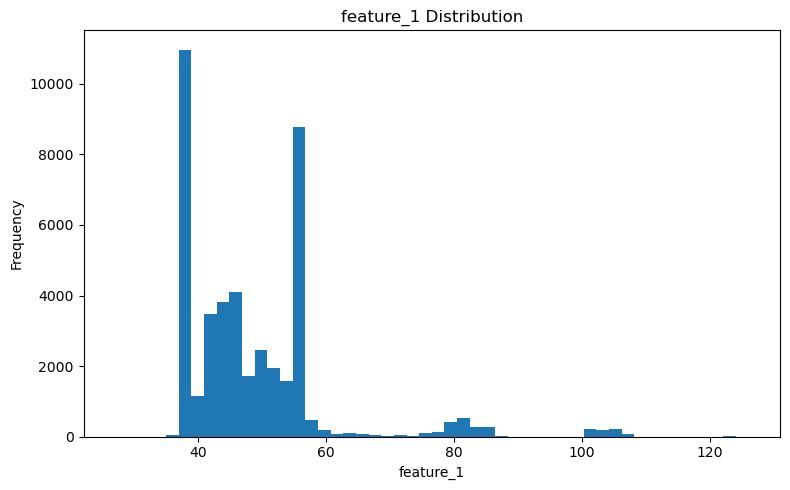

In [ ]:
visualization.plot_histogram(df, column='feature_1', save_path='../assets')

##### Boxplot

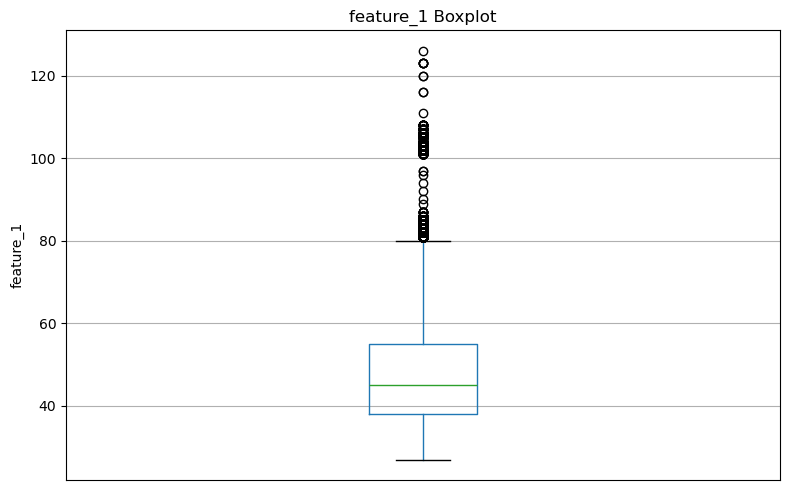

In [ ]:
visualization.plot_boxplot(df, column='feature_1', save_path='../assets/')

#### Featrue 2

##### Histogram

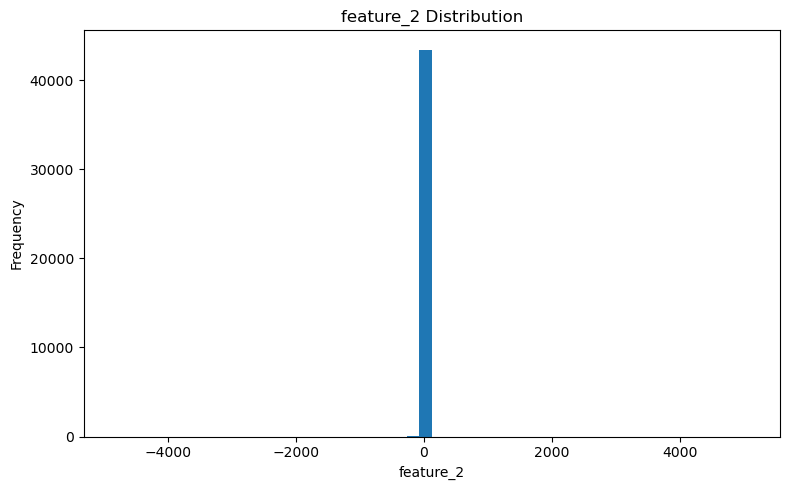

In [ ]:
visualization.plot_histogram(df, column='feature_2', save_path='../assets')

##### Boxplot

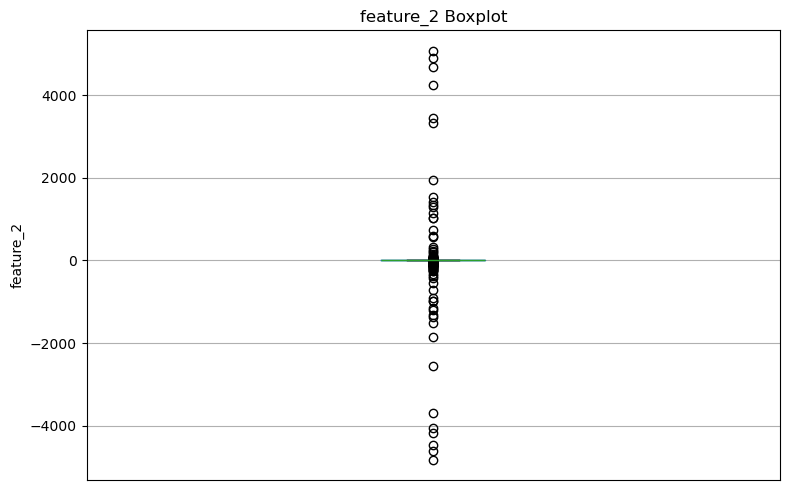

In [ ]:
visualization.plot_boxplot(df, column='feature_2', save_path='../assets/')

#### Feature 3

##### Histogram

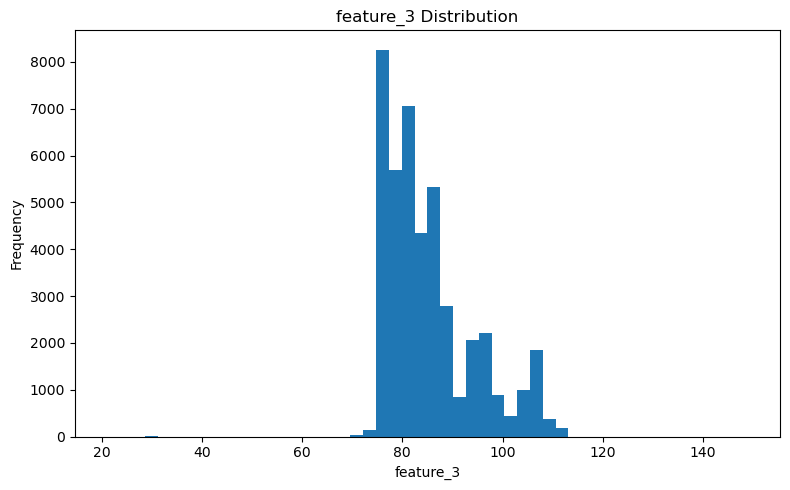

In [ ]:
visualization.plot_histogram(df, column='feature_3', save_path='../assets')

##### Boxplot

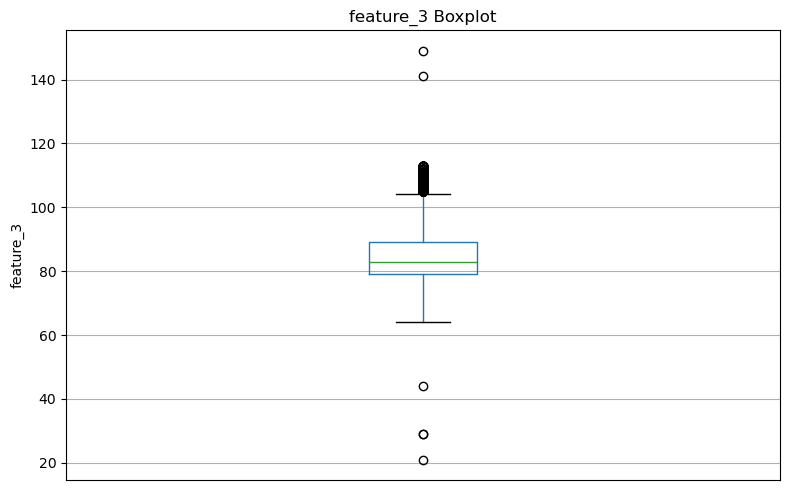

In [ ]:
visualization.plot_boxplot(df, column='feature_3', save_path='../assets/')

#### Feature 4

##### Histogram

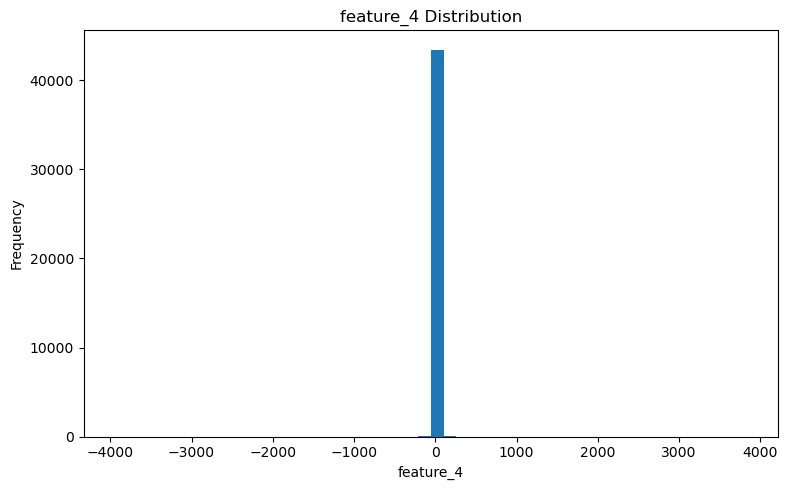

In [ ]:
visualization.plot_histogram(df, column='feature_4', save_path='../assets')

##### Boxplot

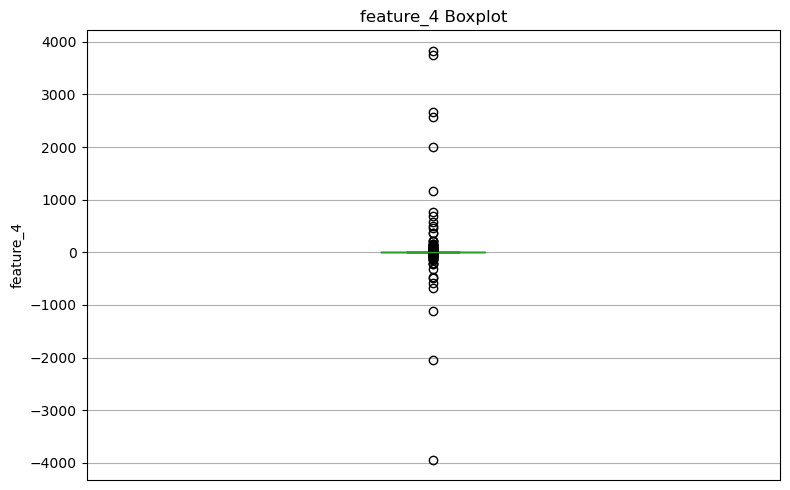

In [ ]:
visualization.plot_boxplot(df, column='feature_4', save_path='../assets/')

#### Feature 5

##### Histogram

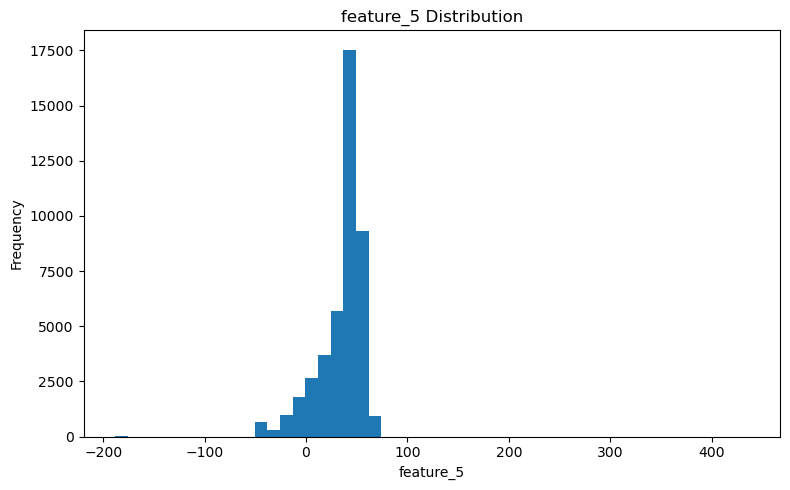

In [ ]:
visualization.plot_histogram(df, column='feature_5', save_path='../assets')

##### Boxplot

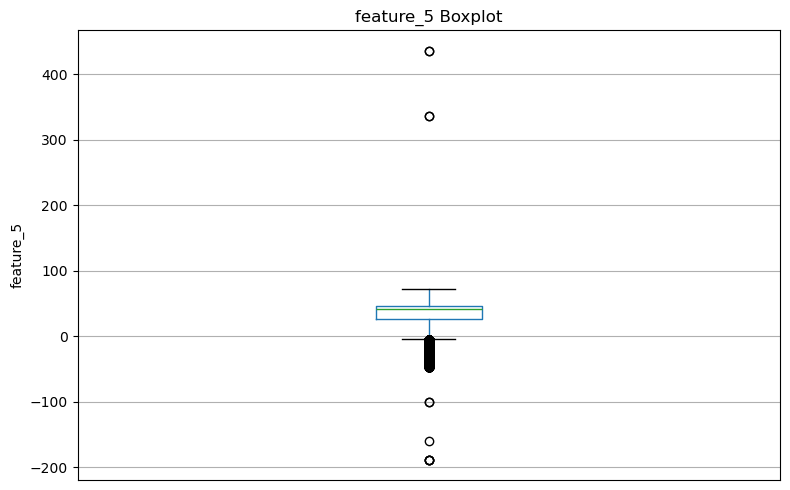

In [ ]:
visualization.plot_boxplot(df, column='feature_5', save_path='../assets/')

#### Feature 6

##### Histogram

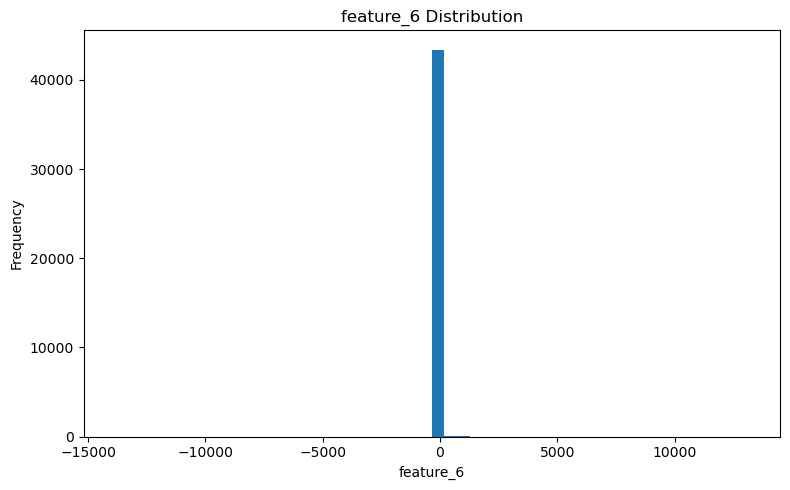

In [ ]:
visualization.plot_histogram(df, column='feature_6', save_path='../assets')

##### Boxplot

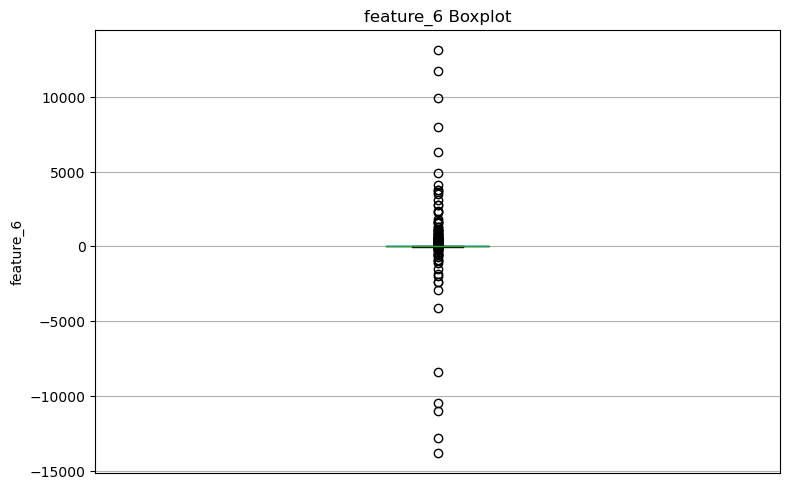

In [ ]:
visualization.plot_boxplot(df, column='feature_6', save_path='../assets/')

#### Feature 7

##### Histogram

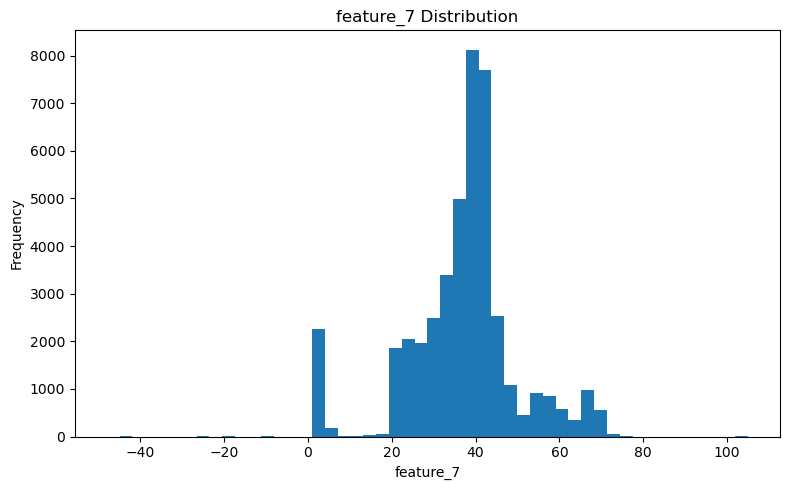

In [ ]:
visualization.plot_histogram(df, column='feature_7', save_path='../assets')

##### Boxplot

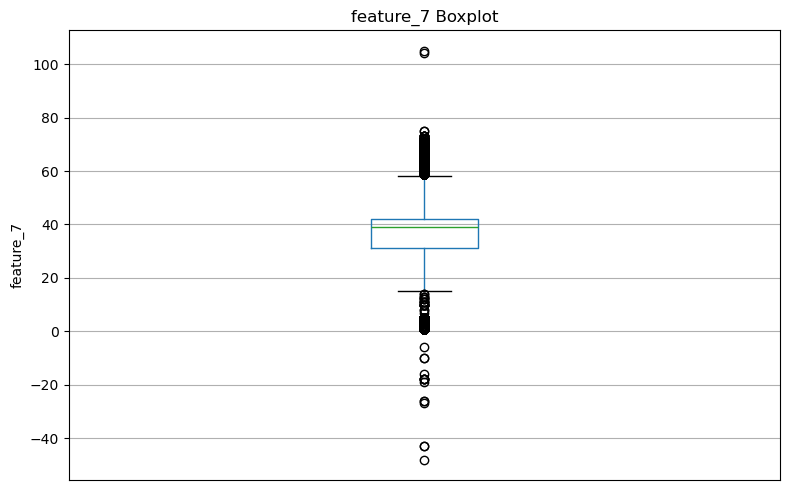

In [ ]:
visualization.plot_boxplot(df, column='feature_7', save_path='../assets/')

#### Feature 8

##### Histogram

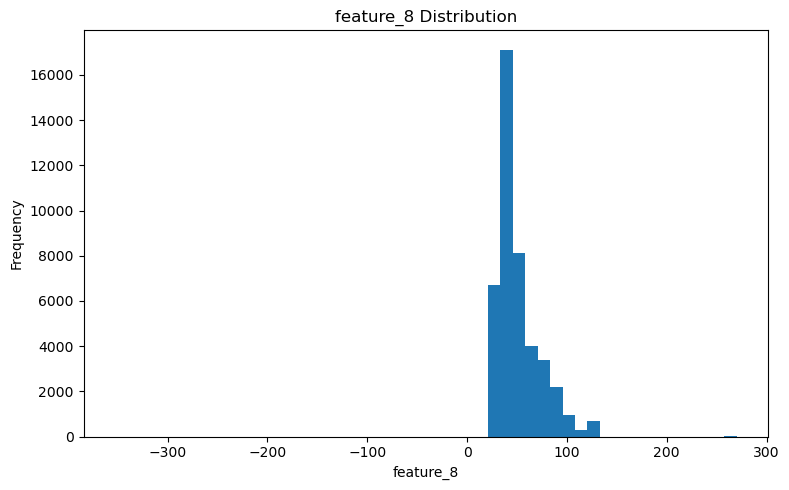

In [ ]:
visualization.plot_histogram(df, column='feature_8', save_path='../assets')

##### Boxplot

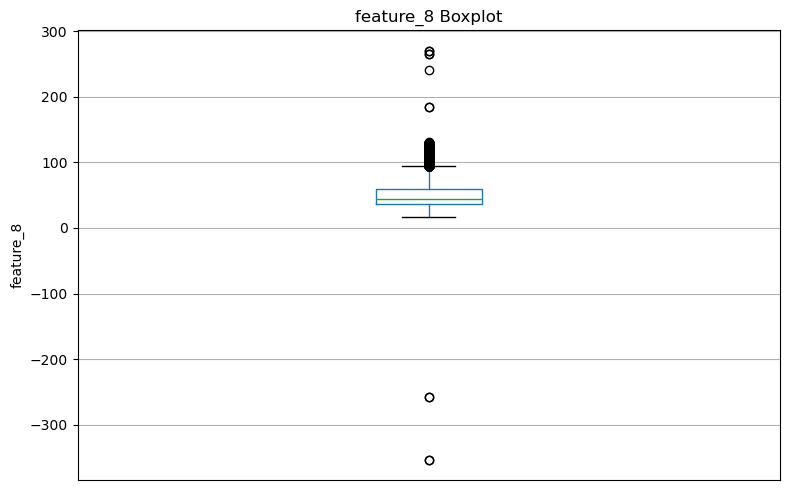

In [ ]:
visualization.plot_boxplot(df, column='feature_8', save_path='../assets/')

#### Feature 9

##### Histogram

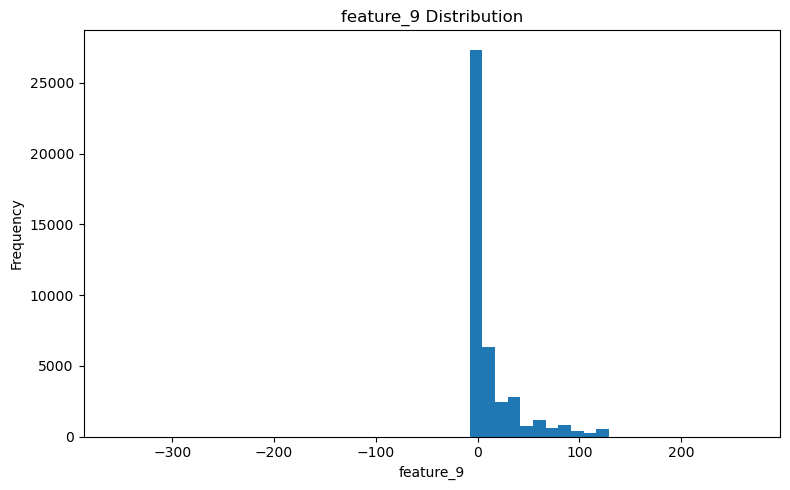

In [ ]:
visualization.plot_histogram(df, column='feature_9', save_path='../assets')

##### Boxplot

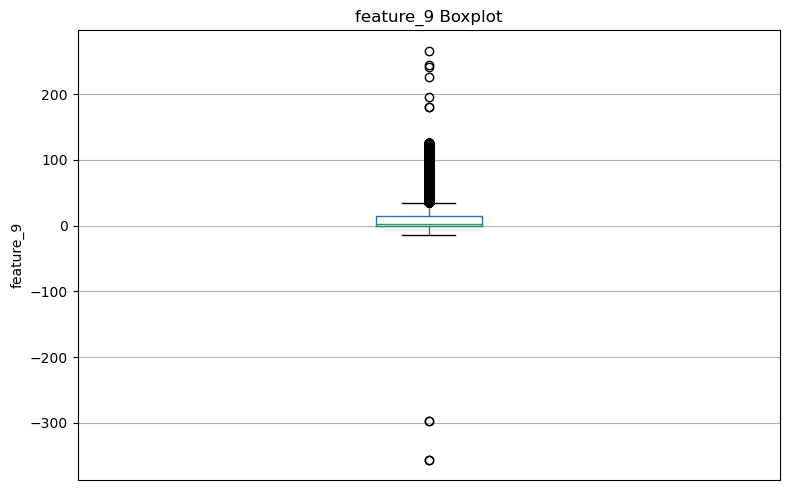

In [ ]:
visualization.plot_boxplot(df, column='feature_9', save_path='../assets/')

### Preprocessing Strategy Overview

| Feature | Distribution Type | Recommended Transformation | Recommended Scaler | Key Rationale Summary |
| :--- | :--- | :--- | :--- | :--- |
| **Feature 1** | Right-Skewed (Positive) | Log Transformation | `RobustScaler` | Normalizes positive right tail; robust to dense valid upper outliers. |
| **Feature 2** | Leptokurtic (Zero-Centered) | Yeo-Johnson | `RobustScaler` | Handles zero/negative values safely; protects against extreme scale distortion. |
| **Feature 3** | Multimodal / Right-Skewed | Log Transformation | `RobustScaler` | Tames right-leaning tail; avoids standard deviation inflation from outliers. |
| **Feature 4** | Leptokurtic (Zero-Centered) | Yeo-Johnson | `RobustScaler` | Safely handles negative/zero bounds; protects normal baseline variance. |
| **Feature 5** | Left-Skewed (Negative Tail) | Yeo-Johnson | `RobustScaler` | Accommodates negative skewness; handles dual-tail extreme outliers. |
| **Feature 6** | Leptokurtic (Massive Range) | Yeo-Johnson | `RobustScaler` | Manages extreme negative/positive spans; prevents mean distortion. |
| **Feature 7** | Multimodal / Complex | Yeo-Johnson | `RobustScaler` | Handles multi-cluster structure and negative values effectively. |
| **Feature 8** | Right-Skewed (Dual-Tail) | Yeo-Johnson | `RobustScaler` | Mitigates right skew with negative extremes; relies on robust IQR metrics. |
| **Feature 9** | Right-Skewed (Dual-Tail) | Yeo-Johnson | `RobustScaler` | Stabilizes heavy zero-concentration tail while bypassing extreme outliers. |


<h2 align="center">3. Dataset Preparation</h2>

This stage includes separating features and target variables, splitting the data into training, validation, and test sets, applying the selected transformations and scaling techniques, and converting the processed data into a format suitable for neural network training.

### 3.1. Feature & Target Separation

In [ ]:
X = df.drop("target", axis=1)

y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (43500, 9)
y shape: (43500,)


### 3.2. Train / Validation / Test Split

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("X_train shape:", X_train.shape)
print("X_valid", X_valid.shape)
print("X_test:", X_test.shape)

X_train shape: (30450, 9)
X_valid (6525, 9)
X_test: (6525, 9)


### 3.3. Apply Feature Transformations

#### Feature 1

In [ ]:
X_train["feature_1_log"] = np.log1p(X_train["feature_1"])

X_valid["feature_1_log"] = np.log1p(X_valid["feature_1"])

X_test["feature_1_log"] = np.log1p(X_test["feature_1"])

#### Feature 2

In [ ]:
transformer = PowerTransformer(method="yeo-johnson")

X_train["feature_2_yeo"] = transformer.fit_transform(X_train[["feature_2"]])


X_valid["feature_2_yeo"] = transformer.transform(X_valid[["feature_2"]])


X_test["feature_2_yeo"] = transformer.transform(X_test[["feature_2"]])

#### Feature 3

In [14]:
X_train["feature_3_log"] = np.log1p(X_train["feature_3"])

X_valid["feature_3_log"] = np.log1p(X_valid["feature_3"])

X_test["feature_3_log"] = np.log1p(X_test["feature_3"])